# Rebuttal: Does conditioning on questions improve performance?

* TLDR: It never hurts and helps a decent amount on bioasq for one metric.

In [2]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('../..')
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np


from copy import deepcopy
import seaborn as sns

import wandb
api = wandb.Api()
api.entity = 'goatml'

In [44]:
# export to eval file
def get_vals(x):
    return x['mean'], x['bootstrap']['low'], x['bootstrap']['high']

def get_vals2(x):
    return x['means'], x['low'], x['high']


def get_perfs(metrics):
    data = []
    for method in metrics['performance']:
        mean, low, high = get_vals(metrics['performance'][method])
        data.append([method, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'means', 'low', 'high'])
    return df.set_index('method')

def plot_bar(df, color='C0', ax=None):
    if ax is None:
        ax = plt.subplots()

    df.plot.bar(y='means', yerr=[df.means - df.low, df.high - df.means], color=color, ax=ax)

def get_uncertainty_df(metrics):
    data = []
    for method in metrics['uncertainty']:
        for metric in metrics['uncertainty'][method]:
            mean, low, high = get_vals(metrics['uncertainty'][method][metric])
            data.append([method, metric, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'metric', 'means', 'low', 'high'])
    
    df = df.set_index('method')

    def get_base_method(x):
        if 'p_false' in x:
            return 'p_false'
        elif 'p_ik' in x:
            return 'p_ik'
        elif 'regular_entropy' in x:
            return 'regular_entropy'
        elif 'cluster_assignment' in x:
            return x
        elif 'semantic_entropy' in x:
            return 'semantic_entropy'
        else:
            raise
    df['base_method'] = df.index.map(get_base_method)
    return df

def plot_bar_uncertainty(pdf, metric, remove='_UNANSWERABLE', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    tmp = pdf
    # filter out unanswerable
    if remove is not None:
        tmp = tmp[tmp.index.map(lambda x: remove not in x)]
    tmp = tmp.reset_index()
    tmp = tmp.set_index('metric').loc[metric]
    tmp = tmp.set_index('method')
    tmp = tmp.sort_values('base_method')

    b2c = {m:f'C{i}' for i, m in enumerate(tmp.base_method.unique())}
    basemethod2color = lambda x: b2c[x]

    plot_bar(tmp, color=tmp.base_method.map(basemethod2color), ax=ax)
    ax.grid(axis='y', zorder=-10, alpha=0.3)

In [14]:
def restore_file(wandb_id, filenames=['wandb-summary.json', 'config.yaml']):
    files_dir = 'notebooks/restored_files'    
    os.system(f'mkdir -p {files_dir}')

    run = api.run(f'goatml/semantic_uncertainty/{wandb_id}')
    # run = api.run(f'goatml/uncertainty/{wandb_id}')
    out = []

    for filename in filenames:
        
        path = f'{files_dir}/{filename}'
        os.system(f'rm -rf {path}')
        run.file(filename).download(root=files_dir, replace=True, exist_ok=False)
    
        if filename.endswith('.pkl'):
            with open(path, 'rb') as f:
                out.append(pickle.load(f))
        elif filename.endswith('.yaml'):
            with open(path, 'r') as f:
                out.append(yaml.safe_load(f))
        elif filename.endswith('.json'):
            with open(path, 'r') as f:
                out.append(json.load(f))
        else:
            raise

    return out

In [26]:
# CoQ = condition on question
runs = {
    '0j29p31i': 'trivia-qa',
    'lzkko2ks': 'trivia-qa-CoQ',
    '4ug9fcne': 'bioasq',
    'iazvobw9': 'bioasq-CoQ'
}

all_configs, all_results = {}, {}

for wandb_id in runs:
    all_results[wandb_id], all_configs[wandb_id] = restore_file(wandb_id)


Can we improve accuracy by instead voting the answer from the (high-temperature) clusters?

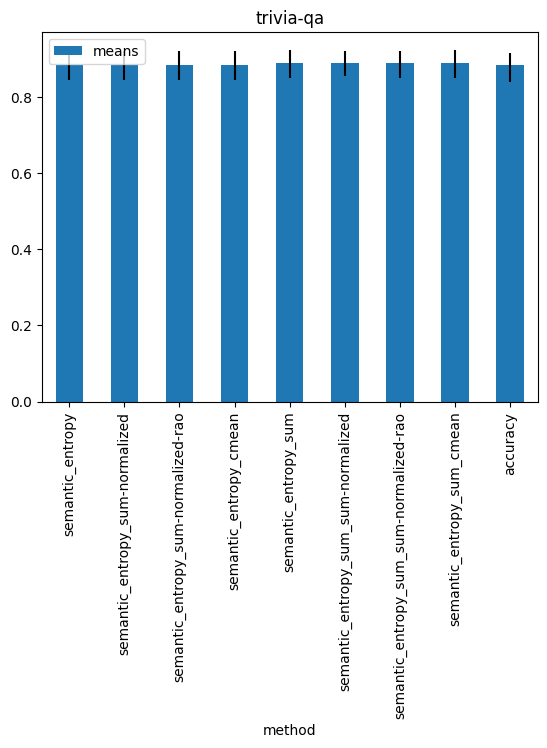

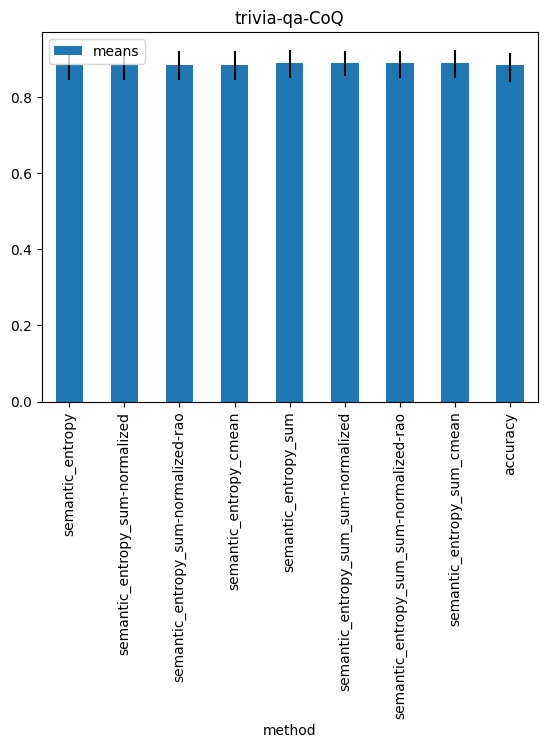

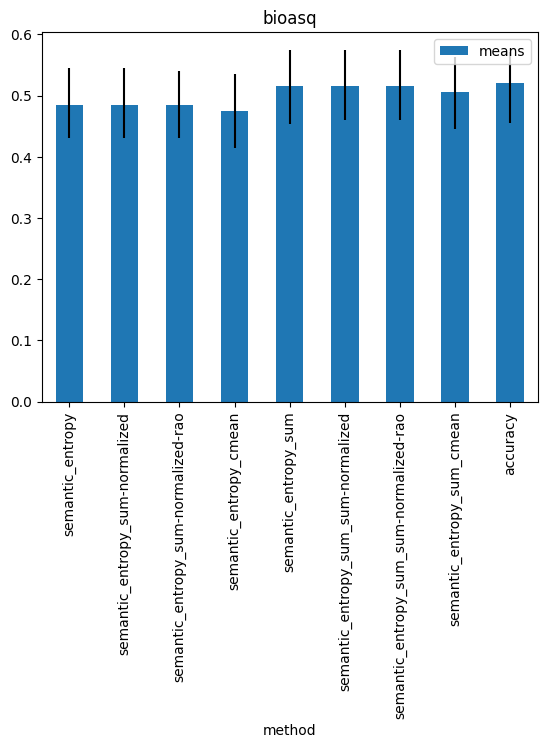

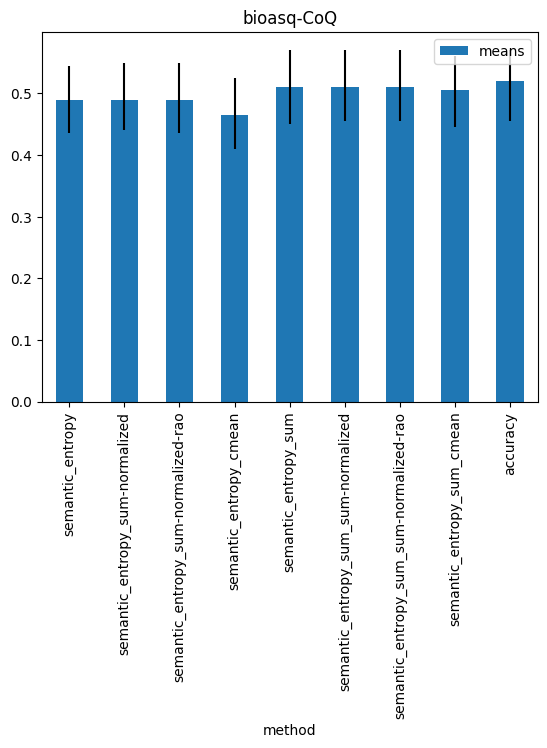

In [27]:
for wandb_id, run_name in runs.items():
    config = all_configs[wandb_id]
    results = all_results[wandb_id]

    df = get_perfs(results)
    plot_bar(df)
    plt.gca().set_title(run_name)


It seems like we do not significantly improve accuracy doing this. 

If anything, we should probably just trust the low-temperature generation.

In [28]:
metric_names = [
    'AUROC',
    'area_under_thresholded_accuracy',
    'mean_uncertainty',
    'accuracy_at_0.8_answer_fraction',
    'accuracy_at_0.9_answer_fraction',
    'accuracy_at_0.95_answer_fraction'
]

pdfs = {}
for wandb_id in runs:
    results = all_results[wandb_id]
    pdfs[wandb_id] = get_uncertainty_df(results)

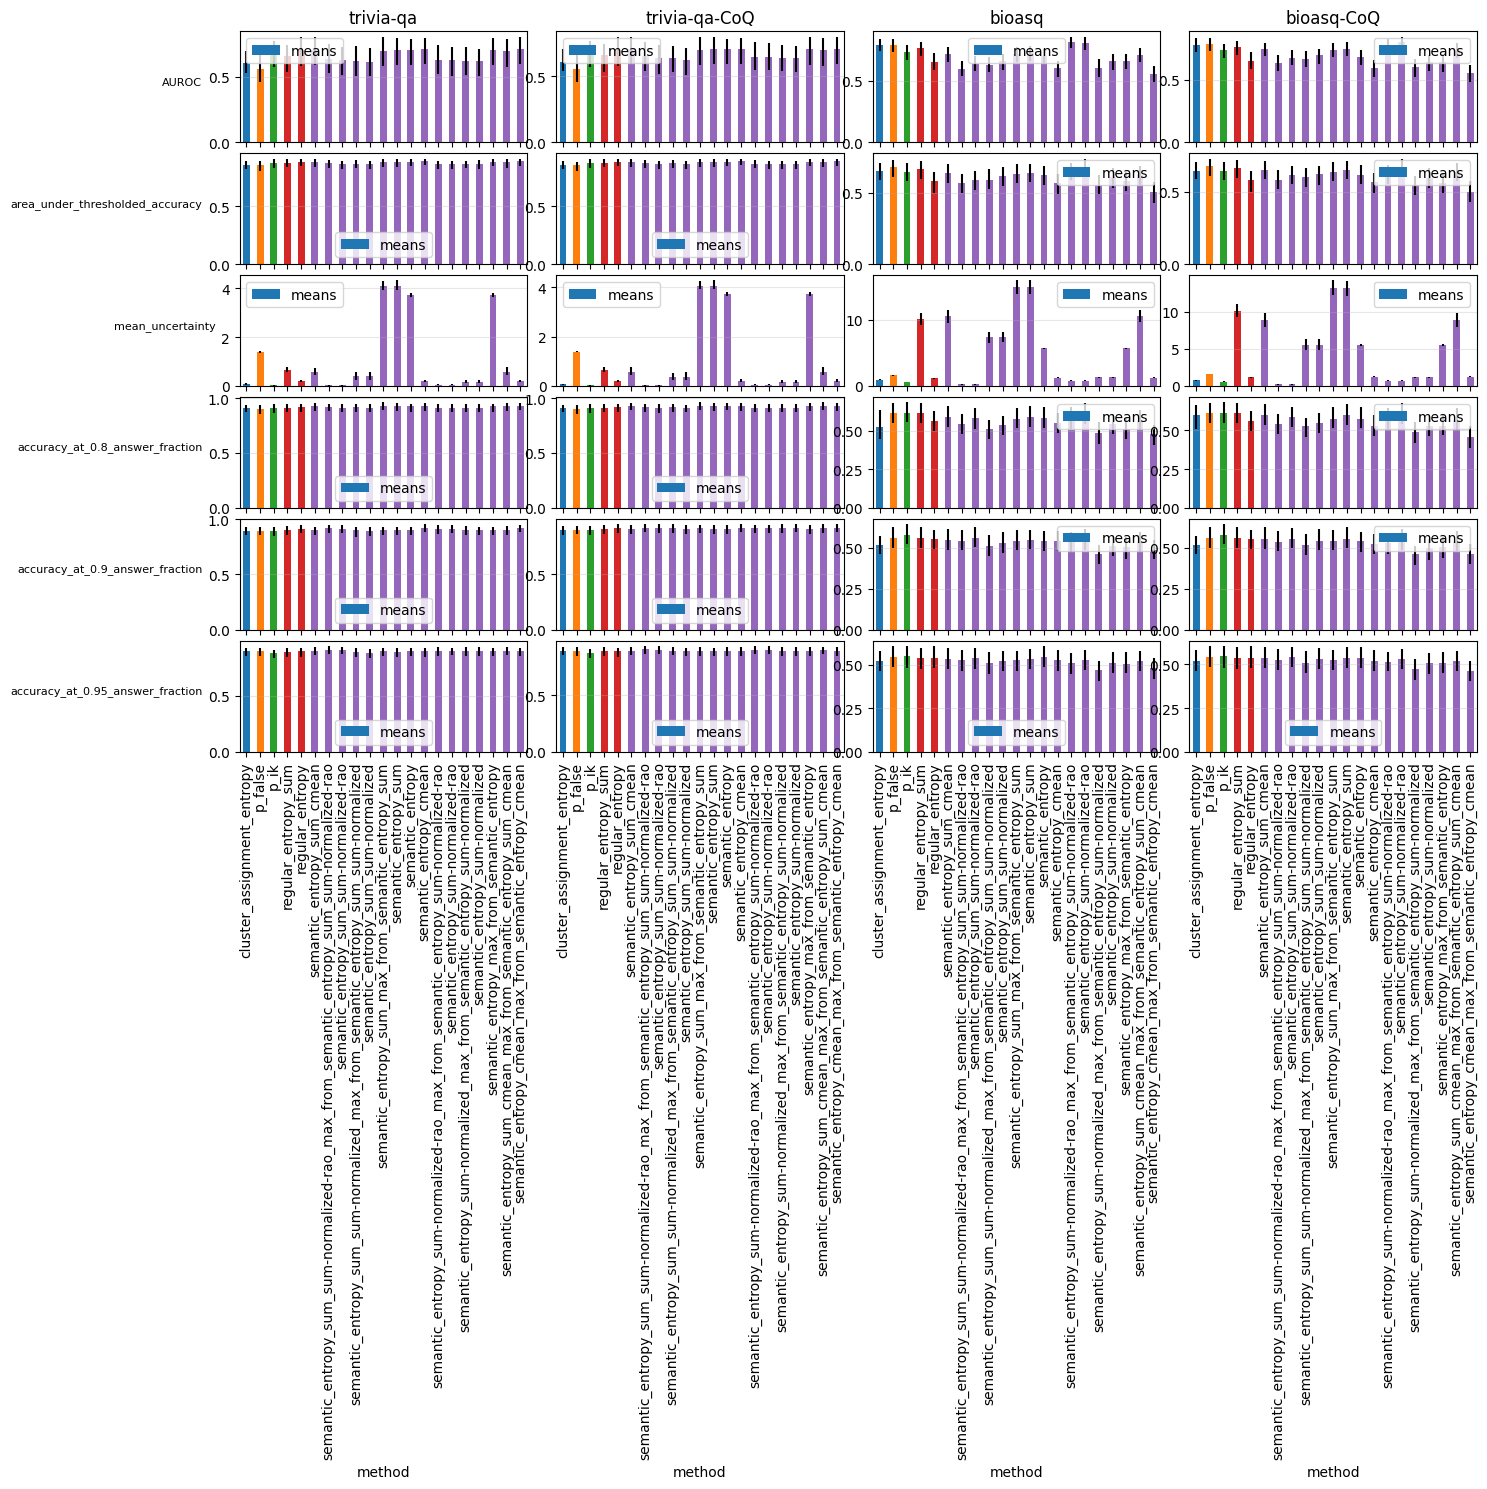

In [29]:
fig, axes_2d = plt.subplots(len(metric_names), len(runs), sharex=True, figsize=(15, 15), dpi=100)
# fig.suptitle(config['dataset']['value'] + ' '+ plt.gca().get_title())
for k, (name, axes) in enumerate(zip(list(metric_names), axes_2d)):

    for i, (ax, wandb_id) in enumerate(zip(axes, runs)):
        plot_bar_uncertainty(pdfs[wandb_id], name, ax=ax)

        if i == 0:
            ax.set_ylabel(name, fontsize=8, rotation=0, ha='right')

        if k == 0:
            ax.set_title(runs[wandb_id])


plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [80]:
runids = list(pdfs.keys())

tmp = pd.DataFrame(pdfs[runids[0]])
tmp['run'] = runs[runids[0]]

for runid in runids[1:]:
    tmp2 = pd.DataFrame(pdfs[runid])
    tmp2['run'] = runs[runid]
    
    tmp = pd.concat([tmp, tmp2])

all_runs = tmp.reset_index()

/tmp/ipykernel_1052206/1764243749.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1052206/1764243749.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


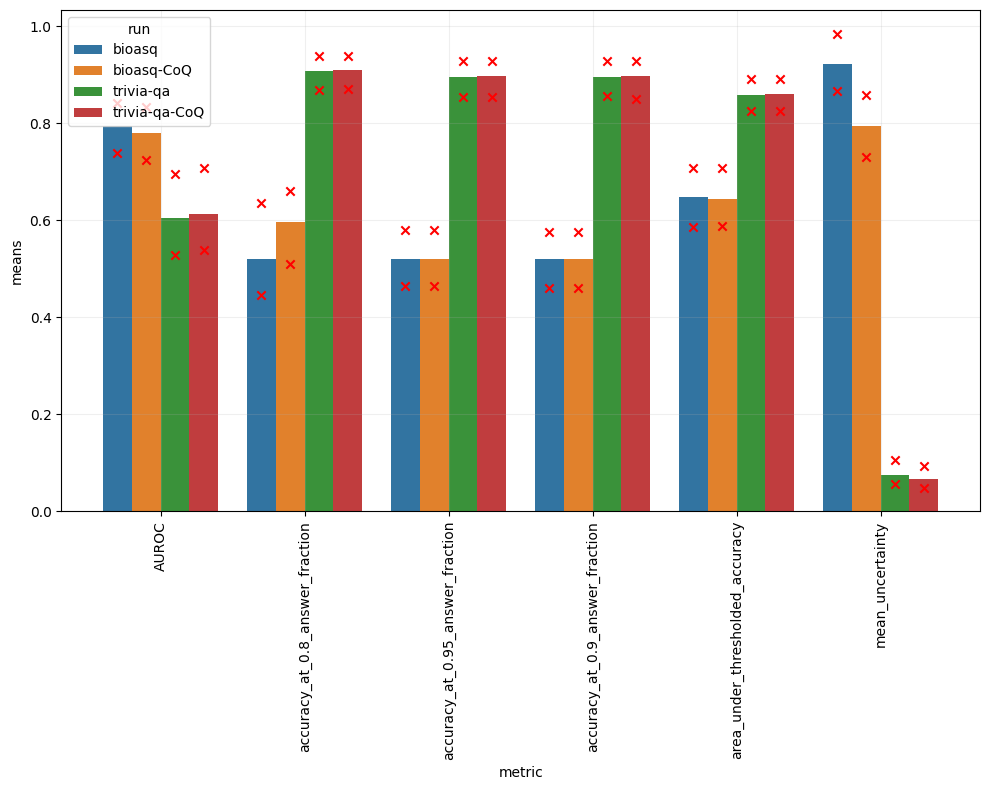

In [81]:
df2 = deepcopy(all_runs)
df2 = df2[all_runs.method == 'cluster_assignment_entropy']
df2 = df2.sort_values(['run', 'metric'])

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="metric",       # x variable name
    y="means",       # y variable name
    hue="run",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

/tmp/ipykernel_1052206/1448009336.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df2[all_runs.metric != 'mean_uncertainty']
/tmp/ipykernel_1052206/1448009336.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1052206/1448009336.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


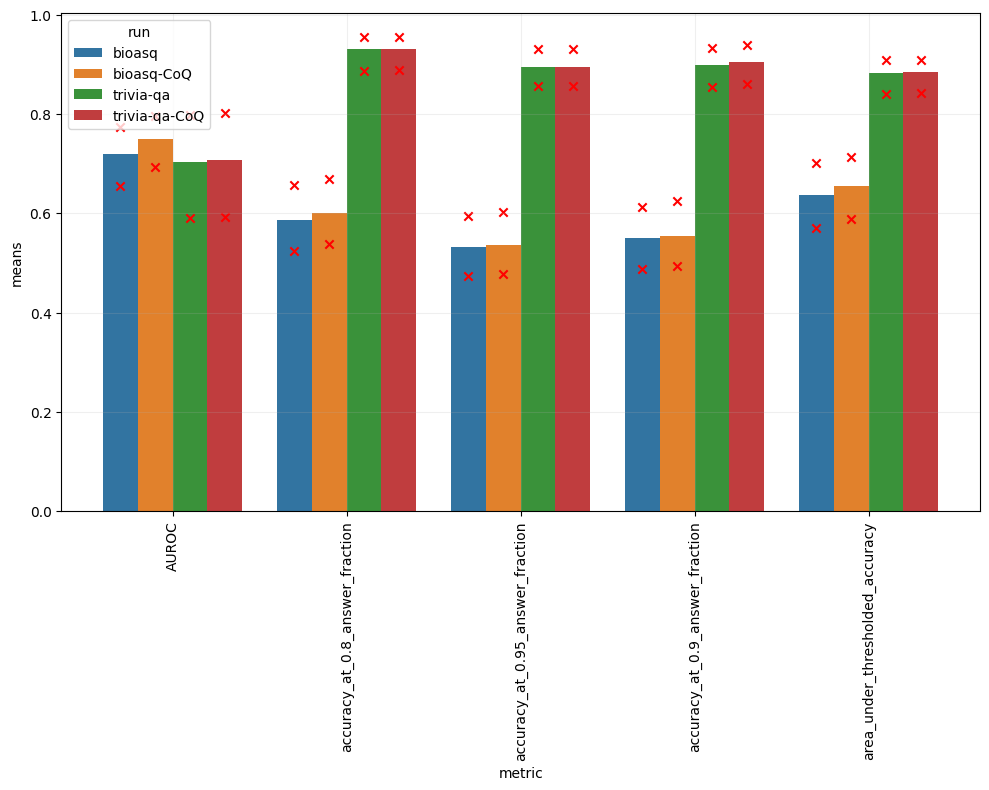

In [83]:
df2 = deepcopy(all_runs)
df2 = df2[all_runs.method == 'semantic_entropy_sum_cmean']
df2 = df2[all_runs.metric != 'mean_uncertainty']

df2 = df2.sort_values(['run', 'metric'])

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="metric",       # x variable name
    y="means",       # y variable name
    hue="run",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()